<a href="https://colab.research.google.com/github/abbasusman0009/traffic_model_predictions/blob/main/Copy_of_drive_me_crazy_pdformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy pandas matplotlib scikit-learn torch -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, math

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.nn.functional as torch_F
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Libraries ready')
print(f'   Device: {device}')

✅ Libraries ready
   Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ✏️ Change this to your file path
FILE_PATH = '/content/drive/MyDrive/pems04.npz'
SAVE_DIR  = '/content/drive/MyDrive'

raw  = np.load(FILE_PATH, allow_pickle=True)
data = raw['data']   # shape: (T, N, F)

T, N, n_feat = data.shape
STEPS_PER_DAY = 288

print(f'✅ PeMS04 loaded')
print(f'   Shape    : {data.shape}')
print(f'   Duration : {T / STEPS_PER_DAY:.1f} days')
print(f'   Sensors  : {N}')

# Use flow only (feature 0)
flow = data[:, :, 0]   # shape: (T, N)

Mounted at /content/drive
✅ PeMS04 loaded
   Shape    : (16992, 307, 3)
   Duration : 59.0 days
   Sensors  : 307


Building 307x307 delay matrix (this takes a moment)...
✅ Delay matrix built — shape: (307, 307)
   Mean delay : 3.50 steps
   Max delay  : 12 steps
   (1 step = 5 minutes)


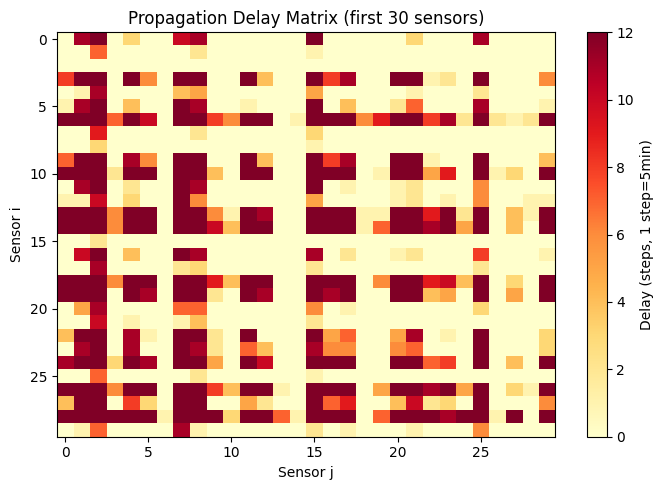

In [ ]:
# Computing full N×N cross-correlation is expensive for large N.
# We use a fast approximation: normalised dot-product on small sample.
# Max lag = 12 steps = 1 hour (enough to capture propagation delays)

MAX_LAG    = 12    # max delay steps we consider
N_SAMPLE   = 2000  # use first 2000 timesteps for speed

print(f'Building {N}x{N} delay matrix (this takes a moment)...')

flow_sample = flow[:N_SAMPLE]   # (N_SAMPLE, N)

# Normalize each sensor to zero mean
flow_z = flow_sample - flow_sample.mean(axis=0, keepdims=True)
flow_z = flow_z / (flow_z.std(axis=0, keepdims=True) + 1e-8)

delay_matrix = np.zeros((N, N), dtype=np.int32)

for i in range(N):
    for j in range(N):
        if i == j:
            delay_matrix[i, j] = 0
            continue
        # Cross-correlation at different lags
        best_lag  = 0
        best_corr = -999
        for lag in range(0, MAX_LAG + 1):
            if lag == 0:
                corr = np.dot(flow_z[:, i], flow_z[:, j])
            else:
                corr = np.dot(flow_z[lag:, i], flow_z[:-lag, j])
            if corr > best_corr:
                best_corr = corr
                best_lag  = lag
        delay_matrix[i, j] = best_lag

print(f'✅ Delay matrix built — shape: {delay_matrix.shape}')
print(f'   Mean delay : {delay_matrix.mean():.2f} steps')
print(f'   Max delay  : {delay_matrix.max()} steps')
print(f'   (1 step = 5 minutes)')

# Visualise a corner of the delay matrix
plt.figure(figsize=(7, 5))
plt.imshow(delay_matrix[:30, :30], cmap='YlOrRd', aspect='auto')
plt.colorbar(label='Delay (steps, 1 step=5min)')
plt.title('Propagation Delay Matrix (first 30 sensors)')
plt.xlabel('Sensor j')
plt.ylabel('Sensor i')
plt.tight_layout()
plt.show()

In [ ]:
SEQ_IN  = 12
SEQ_OUT = 12

# Normalize
train_end = int(T * 0.7)
scaler    = StandardScaler()
scaler.fit(flow[:train_end])
flow_norm = scaler.transform(flow)

# Build sequences
def make_sequences(arr, seq_in, seq_out):
    X, y = [], []
    for t in range(len(arr) - seq_in - seq_out):
        X.append(arr[t          : t + seq_in])
        y.append(arr[t + seq_in : t + seq_in + seq_out])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_all, y_all = make_sequences(flow_norm, SEQ_IN, SEQ_OUT)

n      = len(X_all)
tr_end = int(n * 0.7)
vl_end = int(n * 0.8)

X_train, y_train = X_all[:tr_end],       y_all[:tr_end]
X_val,   y_val   = X_all[tr_end:vl_end], y_all[tr_end:vl_end]
X_test,  y_test  = X_all[vl_end:],       y_all[vl_end:]

print('✅ Data ready')
print(f'   X shape : {X_all.shape}')
print(f'   y shape : {y_all.shape}')
print(f'   Train   : {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

✅ Data ready
   X shape : (16968, 12, 307)
   y shape : (16968, 12, 307)
   Train   : 11877  |  Val: 1697  |  Test: 3394


In [ ]:
class TemporalAttention(nn.Module):
    """Standard multi-head self-attention over the time dimension."""
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          dropout=0.1, batch_first=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (batch, seq, d_model)
        out, _ = self.attn(x, x, x)
        return self.norm(x + out)   # residual connection


class SpatialAttentionWithDelay(nn.Module):
    """
    Spatial attention across sensors, biased by propagation delay.
    Sensors with shorter delay to each other get higher attention weight.
    This is the core contribution of PDFormer.
    """
    def __init__(self, d_model, n_heads, delay_matrix):
        super().__init__()
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.norm = nn.LayerNorm(d_model)

        # Convert delay matrix to a learnable bias
        # Shorter delay → less penalty → higher attention
        # Shape: (1, 1, N, N) for broadcasting over batch and heads
        delay_bias = -delay_matrix.astype(np.float32) / (delay_matrix.max() + 1e-8)
        self.register_buffer('delay_bias',
                             torch.tensor(delay_bias, dtype=torch.float32).unsqueeze(0).unsqueeze(0))
        # Learnable scale for the delay bias
        self.delay_scale = nn.Parameter(torch.ones(1))

    def forward(self, x):
        # x: (batch, N, d_model)  — spatial dimension is N sensors
        B, N, D = x.shape
        H, dk   = self.n_heads, self.d_k

        # Project to Q, K, V and split into heads
        Q = self.W_q(x).view(B, N, H, dk).transpose(1, 2)  # (B, H, N, dk)
        K = self.W_k(x).view(B, N, H, dk).transpose(1, 2)
        V = self.W_v(x).view(B, N, H, dk).transpose(1, 2)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(dk)  # (B, H, N, N)

        # Add propagation delay bias — the key PDFormer ingredient
        scores = scores + self.delay_scale * self.delay_bias

        attn = torch_F.softmax(scores, dim=-1)
        out  = torch.matmul(attn, V)                        # (B, H, N, dk)
        out  = out.transpose(1, 2).contiguous().view(B, N, D)
        out  = self.W_o(out)
        return self.norm(x + out)   # residual connection


class PDFormerLayer(nn.Module):
    """One full PDFormer encoder layer: temporal → spatial → feed-forward."""
    def __init__(self, d_model, n_heads, delay_matrix, ff_dim=128):
        super().__init__()
        self.temporal = TemporalAttention(d_model, n_heads)
        self.spatial  = SpatialAttentionWithDelay(d_model, n_heads, delay_matrix)
        self.ff       = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model),
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        # x: (batch, seq_in, N, d_model)
        B, T, N, D = x.shape

        # ── Temporal attention: applied per sensor ─────────
        x_t = x.view(B * N, T, D)
        x_t = self.temporal(x_t)
        x   = x_t.view(B, T, N, D)

        # ── Spatial attention: applied per timestep ────────
        x_s = x.view(B * T, N, D)
        x_s = self.spatial(x_s)
        x   = x_s.view(B, T, N, D)

        # ── Feed forward ───────────────────────────────────
        ff_out = self.ff(x)
        x = self.norm(x + ff_out)
        return x


class PDFormer(nn.Module):
    """
    Full PDFormer model.
    Input : (batch, seq_in, N)   — seq_in timesteps, N sensors
    Output: (batch, seq_out, N)  — seq_out future timesteps
    """
    def __init__(self, n_sensors, d_model=32, n_heads=4,
                 n_layers=2, seq_in=12, seq_out=12, delay_matrix=None):
        super().__init__()
        self.seq_out = seq_out

        # Project input from 1 feature → d_model
        self.input_proj = nn.Linear(1, d_model)

        # Stack of PDFormer layers
        self.layers = nn.ModuleList([
            PDFormerLayer(d_model, n_heads, delay_matrix)
            for _ in range(n_layers)
        ])

        # Output: flatten time dim and project to seq_out
        self.output_proj = nn.Linear(seq_in * d_model, seq_out)

    def forward(self, x):
        # x: (batch, seq_in, N)
        B, T, N = x.shape

        # Add feature dim and project
        x = x.unsqueeze(-1)                 # (B, T, N, 1)
        x = self.input_proj(x)              # (B, T, N, d_model)

        # Pass through PDFormer layers
        for layer in self.layers:
            x = layer(x)                    # (B, T, N, d_model)

        # Flatten time × d_model, then project to seq_out per sensor
        x = x.permute(0, 2, 1, 3)          # (B, N, T, d_model)
        x = x.contiguous().view(B, N, -1)  # (B, N, T*d_model)
        x = self.output_proj(x)             # (B, N, seq_out)
        x = x.permute(0, 2, 1)             # (B, seq_out, N)
        return x


# Build the model
model = PDFormer(
    n_sensors    = N,
    d_model      = 32,
    n_heads      = 4,
    n_layers     = 2,
    seq_in       = SEQ_IN,
    seq_out      = SEQ_OUT,
    delay_matrix = delay_matrix
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print('✅ PDFormer model created')
print(f'   Input  : (batch, {SEQ_IN}, {N})')
print(f'   Output : (batch, {SEQ_OUT}, {N})')
print(f'   Total parameters: {total_params:,}')

✅ PDFormer model created
   Input  : (batch, 12, 307)
   Output : (batch, 12, 307)
   Total parameters: 38,670


In [ ]:
# from torch.utils.data import DataLoader, TensorDataset

BATCH_SIZE = 32
EPOCHS     = 20
LR         = 0.001

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val), torch.tensor(y_val)),
    batch_size=BATCH_SIZE, shuffle=False
)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses = []
val_losses   = []

print(f'Training PDFormer for {EPOCHS} epochs...')
print()

for epoch in range(1, EPOCHS + 1):

    # ── Train ───────────────────────────────────────────────
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    # ── Validate ────────────────────────────────────────────
    model.eval()
    vbatch_losses = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb)
            vbatch_losses.append(loss.item())
    val_loss = np.mean(vbatch_losses)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'  Epoch {epoch:2d}/{EPOCHS}  |  Train Loss: {train_loss:.4f}  |  Val Loss: {val_loss:.4f}')

print('\n✅ Training complete!')

Training PDFormer for 20 epochs...

  Epoch  1/20  |  Train Loss: 0.1162  |  Val Loss: 0.1013
  Epoch  2/20  |  Train Loss: 0.0920  |  Val Loss: 0.0973
  Epoch  3/20  |  Train Loss: 0.0900  |  Val Loss: 0.0935
  Epoch  4/20  |  Train Loss: 0.0880  |  Val Loss: 0.0947
  Epoch  5/20  |  Train Loss: 0.0860  |  Val Loss: 0.0946
  Epoch  6/20  |  Train Loss: 0.0839  |  Val Loss: 0.0902
  Epoch  7/20  |  Train Loss: 0.0824  |  Val Loss: 0.0875
  Epoch  8/20  |  Train Loss: 0.0818  |  Val Loss: 0.0881
  Epoch  9/20  |  Train Loss: 0.0810  |  Val Loss: 0.0874
  Epoch 10/20  |  Train Loss: 0.0802  |  Val Loss: 0.0840
  Epoch 11/20  |  Train Loss: 0.0799  |  Val Loss: 0.0855
  Epoch 12/20  |  Train Loss: 0.0800  |  Val Loss: 0.0842
  Epoch 13/20  |  Train Loss: 0.0791  |  Val Loss: 0.0848
  Epoch 14/20  |  Train Loss: 0.0790  |  Val Loss: 0.0834
  Epoch 15/20  |  Train Loss: 0.0784  |  Val Loss: 0.0831
  Epoch 16/20  |  Train Loss: 0.0780  |  Val Loss: 0.0831
  Epoch 17/20  |  Train Loss: 0.0776

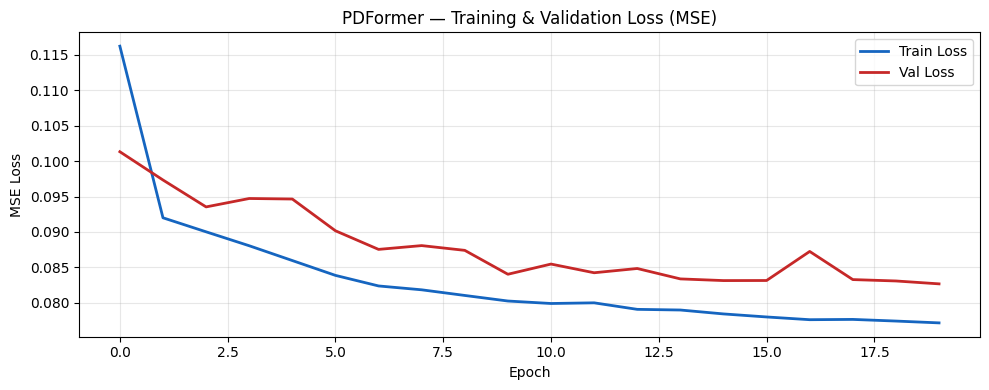

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='#1565C0', linewidth=2)
plt.plot(val_losses,   label='Val Loss',   color='#C62828', linewidth=2)
plt.title('PDFormer — Training & Validation Loss (MSE)', fontsize=12)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Run inference in small batches to avoid GPU out-of-memory
EVAL_BATCH = 32
model.eval()
all_preds = []

with torch.no_grad():
    for i in range(0, len(X_test), EVAL_BATCH):
        xb = torch.tensor(X_test[i : i + EVAL_BATCH]).to(device)
        pb = model(xb).cpu().numpy()
        all_preds.append(pb)
        torch.cuda.empty_cache()   # free GPU memory after each batch

preds_norm = np.concatenate(all_preds, axis=0)   # (samples, seq_out, N)

# Inverse transform to original scale
S, P, Ns   = preds_norm.shape
preds_real = scaler.inverse_transform(preds_norm.reshape(-1, Ns)).reshape(S, P, Ns)
truth_real = scaler.inverse_transform(y_test.reshape(-1, Ns)).reshape(S, P, Ns)

mae  = mean_absolute_error(truth_real.flatten(), preds_real.flatten())
rmse = np.sqrt(mean_squared_error(truth_real.flatten(), preds_real.flatten()))
mape = np.mean(np.abs((truth_real - preds_real) / (truth_real + 1e-5))) * 100

print('=' * 40)
print('  PDFormer — Test Set Results')
print('=' * 40)
print(f'  MAE  : {mae:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 40)

pdformer_results = {'Model': 'PDFormer', 'MAE': round(mae,4),
                    'RMSE': round(rmse,4), 'MAPE': round(mape,2)}

  PDFormer — Test Set Results
  MAE  : 22.0908
  RMSE : 34.4699
  MAPE : 4147306.75%


  MODEL COMPARISON — PeMS04
   Model     MAE    RMSE       MAPE
    LSTM 23.8622 38.9429 14106552.0
PDFormer 22.0908 34.4699  4147307.0

  PDFormer vs LSTM improvement:
    MAE  improved by : 7.4%
    RMSE improved by : 11.5%


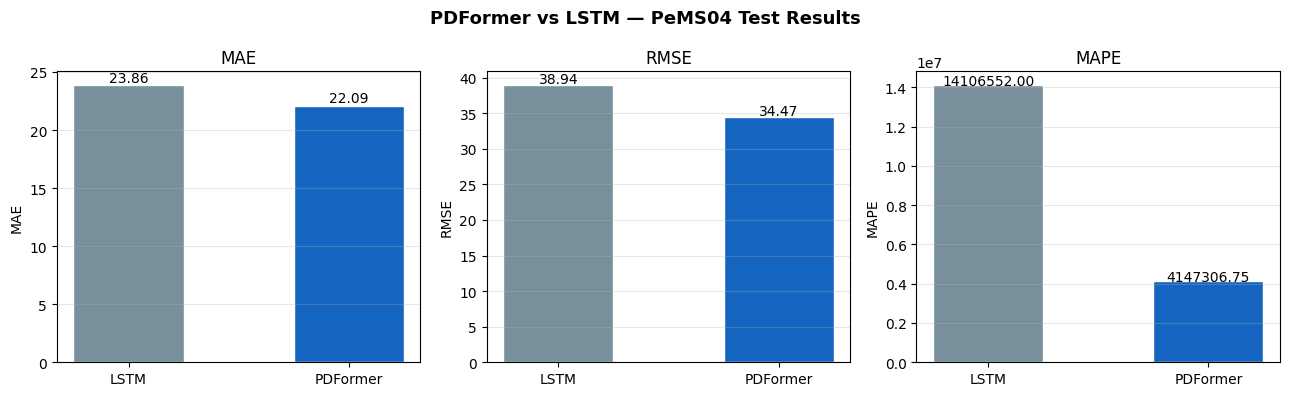

In [ ]:
# Load LSTM results saved from the previous notebook
lstm_path = os.path.join(SAVE_DIR, 'model_results.csv')

if os.path.exists(lstm_path):
    lstm_df = pd.read_csv(lstm_path)
    lstm_results = lstm_df.iloc[0].to_dict()
else:
    # Placeholder if LSTM notebook not run yet
    print('LSTM results file not found — using placeholder values')
    lstm_results = {'Model': 'LSTM', 'MAE': 999, 'RMSE': 999, 'MAPE': 999}

# Build comparison table
compare_df = pd.DataFrame([lstm_results, pdformer_results])
compare_df = compare_df[['Model', 'MAE', 'RMSE', 'MAPE']]

# Compute improvement
lstm_mae  = float(lstm_results['MAE'])
lstm_rmse = float(lstm_results['RMSE'])
mae_imp   = 100 * (lstm_mae  - mae)  / lstm_mae
rmse_imp  = 100 * (lstm_rmse - rmse) / lstm_rmse

print('=' * 50)
print('  MODEL COMPARISON — PeMS04')
print('=' * 50)
print(compare_df.to_string(index=False))
print()
print(f'  PDFormer vs LSTM improvement:')
print(f'    MAE  improved by : {mae_imp:.1f}%')
print(f'    RMSE improved by : {rmse_imp:.1f}%')
print('=' * 50)

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
models  = ['LSTM', 'PDFormer']
colors  = ['#78909C', '#1565C0']
metrics = [
    ('MAE',  [float(lstm_results['MAE']),  mae]),
    ('RMSE', [float(lstm_results['RMSE']), rmse]),
    ('MAPE', [float(lstm_results['MAPE']), mape]),
]

for ax, (metric, vals) in zip(axes, metrics):
    bars = ax.bar(models, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.2f}', ha='center', fontsize=10)

fig.suptitle('PDFormer vs LSTM — PeMS04 Test Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

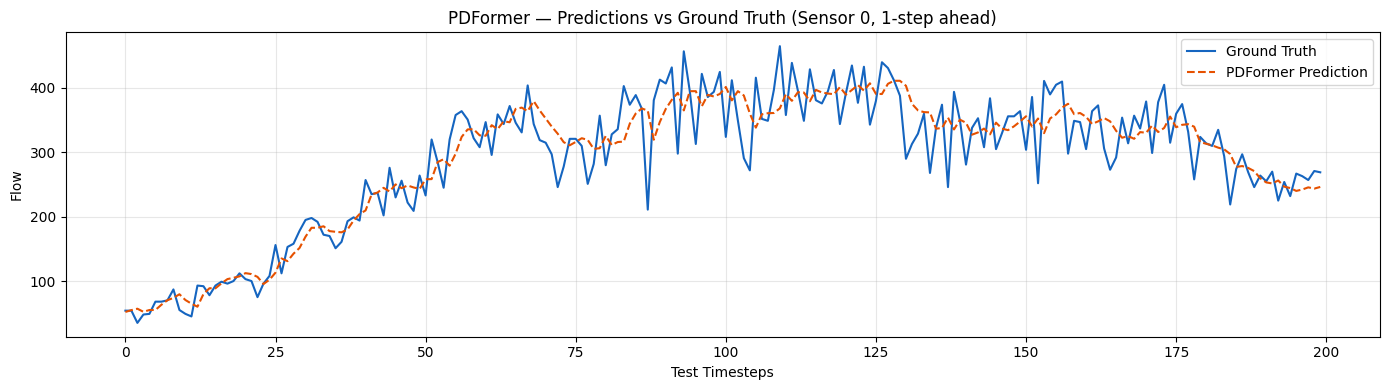

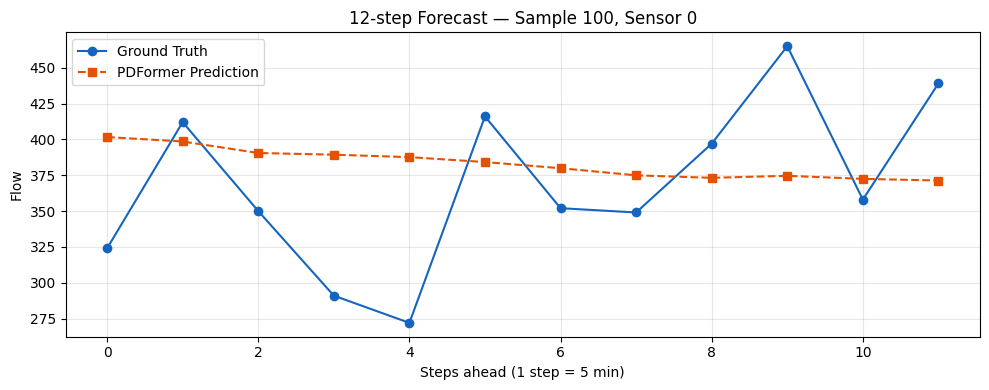

In [ ]:
SENSOR = 0
N_SHOW = 200

pred_plot  = preds_real[:N_SHOW, 0, SENSOR]
truth_plot = truth_real[:N_SHOW, 0, SENSOR]

plt.figure(figsize=(14, 4))
plt.plot(truth_plot, label='Ground Truth',     color='#1565C0', linewidth=1.5)
plt.plot(pred_plot,  label='PDFormer Prediction', color='#E65100',
         linewidth=1.5, linestyle='--')
plt.title(f'PDFormer — Predictions vs Ground Truth (Sensor {SENSOR}, 1-step ahead)', fontsize=12)
plt.xlabel('Test Timesteps')
plt.ylabel('Flow')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 12-step horizon for one sample
SAMPLE = 100
plt.figure(figsize=(10, 4))
plt.plot(range(SEQ_OUT), truth_real[SAMPLE, :, SENSOR],
         'o-', label='Ground Truth',      color='#1565C0')
plt.plot(range(SEQ_OUT), preds_real[SAMPLE, :, SENSOR],
         's--', label='PDFormer Prediction', color='#E65100')
plt.title(f'12-step Forecast — Sample {SAMPLE}, Sensor {SENSOR}', fontsize=12)
plt.xlabel('Steps ahead (1 step = 5 min)')
plt.ylabel('Flow')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Save PDFormer model weights
model_path = os.path.join(SAVE_DIR, 'pdformer_pems04.pt')
torch.save(model.state_dict(), model_path)
print(f'✅ PDFormer model saved → {model_path}')

# Save full comparison results
final_results = pd.DataFrame([lstm_results, pdformer_results])
results_path  = os.path.join(SAVE_DIR, 'model_comparison.csv')
final_results.to_csv(results_path, index=False)
print(f'✅ Comparison results saved → {results_path}')
print(f'   (Upload this CSV to Looker Studio for your dashboard)')

print()
print('=' * 50)
print('  FINAL RESULTS SUMMARY — PeMS04')
print('=' * 50)
print(final_results.to_string(index=False))
print()
print(f'  PDFormer MAE  improvement: {mae_imp:.1f}%')
print(f'  PDFormer RMSE improvement: {rmse_imp:.1f}%')
print()
print('✅ All notebooks complete!')
print('👉 Next: upload model_comparison.csv to Looker Studio for your dashboard')

✅ PDFormer model saved → /content/drive/MyDrive/pdformer_pems04.pt
✅ Comparison results saved → /content/drive/MyDrive/model_comparison.csv
   (Upload this CSV to Looker Studio for your dashboard)

  FINAL RESULTS SUMMARY — PeMS04
   Model     MAE    RMSE       MAPE
    LSTM 23.8622 38.9429 14106552.0
PDFormer 22.0908 34.4699  4147307.0

  PDFormer MAE  improvement: 7.4%
  PDFormer RMSE improvement: 11.5%

✅ All notebooks complete!
👉 Next: upload model_comparison.csv to Looker Studio for your dashboard
